In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
plt.style.use("classic")

In [13]:
soybean_ticker = "ZS=F"
fx_ticker = "THB=X"
start_date = "2023-01-01"
end_date = "2026-05-23"

df_soy = yf.download(soybean_ticker, start=start_date, end=end_date)
df_fx = yf.download(fx_ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [14]:
display(df_soy.head())
df_soy.info()

display(df_fx.head())
df_fx.info()

Price,Close,High,Low,Open,Volume
Ticker,ZS=F,ZS=F,ZS=F,ZS=F,ZS=F
Date,,,,,
2023-01-03,1487.25,1523.25,1485.00,1519.25,2951
2023-01-04,1478.25,1496.25,1477.25,1491.75,2200
2023-01-05,1466.75,1481.25,1462.00,1481.25,1169
2023-01-06,1501.50,1503.25,1471.75,1471.75,2024
2023-01-09,1503.50,1513.00,1502.00,1506.00,446


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 851 entries, 2023-01-03 to 2026-05-22
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, ZS=F)   851 non-null    float64
 1   (High, ZS=F)    851 non-null    float64
 2   (Low, ZS=F)     851 non-null    float64
 3   (Open, ZS=F)    851 non-null    float64
 4   (Volume, ZS=F)  851 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 39.9 KB


Price,Close,High,Low,Open,Volume
Ticker,THB=X,THB=X,THB=X,THB=X,THB=X
Date,,,,,
2023-01-02,34.443001,34.630001,34.215000,34.443001,0
2023-01-03,34.490002,34.490002,34.270000,34.490002,0
2023-01-04,34.380001,34.419998,33.835999,34.380001,0
2023-01-05,33.888000,34.160000,33.768002,33.888000,0
2023-01-06,34.040001,34.071999,33.650002,34.040001,0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 880 entries, 2023-01-02 to 2026-05-22
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, THB=X)   880 non-null    float64
 1   (High, THB=X)    880 non-null    float64
 2   (Low, THB=X)     880 non-null    float64
 3   (Open, THB=X)    880 non-null    float64
 4   (Volume, THB=X)  880 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 41.2 KB


In [15]:
soy_values = df_soy['Close'].to_numpy().flatten()
fx_values = df_fx['Close'].to_numpy().flatten()

soy_dates = df_soy.index.to_numpy()
fx_dates = df_fx.index.to_numpy()
print(type(soy_dates))
print(soy_dates.shape)
print(fx_dates.shape)

<class 'numpy.ndarray'>
(851,)
(880,)


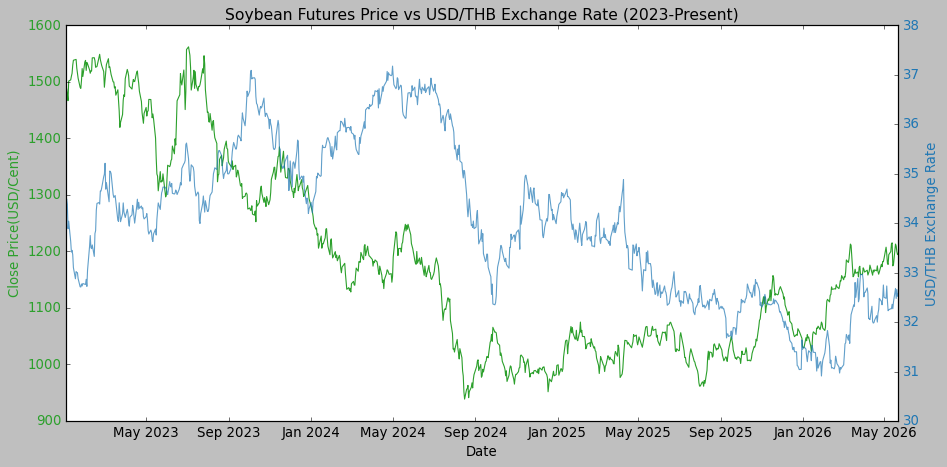

In [16]:
fig, ax1 = plt.subplots(figsize = (12,6))

color = 'tab:green'
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price(USD/Cent)', color=color)
ax1.plot(soy_dates, soy_values, color=color, label='Soybean (CBOT)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('USD/THB Exchange Rate', color=color)
ax2.plot(fx_dates, fx_values, color=color, alpha=0.7, label='USD/THB')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Soybean Futures Price vs USD/THB Exchange Rate (2023-Present)', fontsize=14)
fig.tight_layout()
plt.show()